```
py -m pip install torch torchvision opencv-python
```

In [4]:
import urllib.request

url = "https://www.stockvault.net/data/2010/03/11/113202/thumb16.jpg"
urllib.request.urlretrieve(url, "data/flower.jpg")

('data/flower.jpg', <http.client.HTTPMessage at 0x17019885650>)

In [9]:
import torch
import torchvision
from torchvision.transforms import functional as F
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights
import cv2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=weights)
model.to(device)
model.eval()

labels = weights.meta["categories"]

img_path = "data/flower.jpg"
image = cv2.imread(img_path)
if image is None:
    raise FileNotFoundError(img_path)

orig = image.copy()
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
tensor = F.to_tensor(image_rgb).unsqueeze(0).to(device)

with torch.no_grad():
    preds = model(tensor)

boxes = preds[0]["boxes"]
scores = preds[0]["scores"]
classes = preds[0]["labels"]

for box, score, cls in zip(boxes, scores, classes):
    if score < 0.5:
        break

    x1, y1, x2, y2 = box.int().tolist()
    label = f"{labels[cls.item()]}: {score:.2f}"

    cv2.rectangle(orig, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(orig, label, (x1, max(y1 - 10, 10)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

cv2.imwrite("data/output.jpg", orig)


True

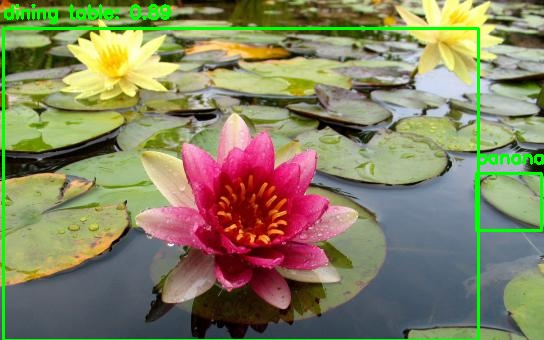

In [10]:
from PIL import Image

img = Image.open('data/output.jpg')
img
